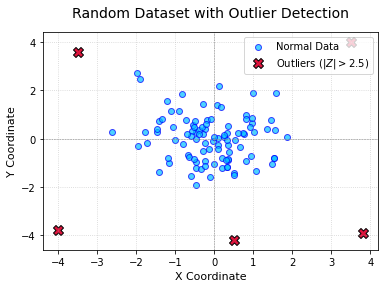

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate normal data distribution (100 points)
x_normal = np.random.normal(0, 1, 100)
y_normal = np.random.normal(0, 1, 100)

# 2. Inject some explicit extreme outliers to simulate real-world anomalies
x_outliers = np.array([3.5, -4.0, 3.8, -3.5, 0.5])
y_outliers = np.array([4.0, -3.8, -3.9, 3.6, -4.2])

# Combine into a single consolidated dataset
x = np.concatenate([x_normal, x_outliers])
y = np.concatenate([y_normal, y_outliers])

# 3. Mathematically identify outliers using Z-score
# Any point further than 2.5 standard deviations from the mean on either axis is flagged
z_x = (x - np.mean(x)) / np.std(x)
z_y = (y - np.mean(y)) / np.std(y)

is_outlier = (np.abs(z_x) > 2.5) | (np.abs(z_y) > 2.5)

# Separate the dataset for distinct plotting groups
x_clean = x[~is_outlier]
y_clean = y[~is_outlier]

x_out = x[is_outlier]
y_out = y[is_outlier]

# 4. Generate the scatter plot
plt.scatter(x_clean, y_clean, color='deepskyblue', alpha=0.7, edgecolors='b', label='Normal Data')
plt.scatter(x_out, y_out, color='crimson', s=100, marker='X', edgecolors='black', label='Outliers ($|Z| > 2.5$)')

# Add descriptive labels, titles, and clean formatting
plt.title('Random Dataset with Outlier Detection', fontsize=14, pad=15)
plt.xlabel('X Coordinate', fontsize=11)
plt.ylabel('Y Coordinate', fontsize=11)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

# Save the plot image cleanly
plt.savefig('data/outliers_scatter.png', bbox_inches='tight', dpi=150)
#plt.show()